In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arjuntejaswi/plant-village")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/arjuntejaswi/plant-village


In [2]:
import os
import shutil

# Original dataset path
dataset_path = "/kaggle/input/datasets/arjuntejaswi/plant-village/PlantVillage"

# New dataset containing only potato classes
new_dataset_path = "/kaggle/working/Potato_Disease"

# Classes we want
classes = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]

# Create new dataset folder
os.makedirs(new_dataset_path, exist_ok=True)

# Copy only potato folders
for class_name in classes:
    source = os.path.join(dataset_path, class_name)
    destination = os.path.join(new_dataset_path, class_name)

    if os.path.exists(source):
        shutil.copytree(source, destination, dirs_exist_ok=True)
        print(f"Copied: {class_name}")
    else:
        print(f"Not found: {class_name}")

print("\nDataset created at:", new_dataset_path)

Copied: Potato___Early_blight
Copied: Potato___Late_blight
Copied: Potato___healthy

Dataset created at: /kaggle/working/Potato_Disease


In [3]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [4]:
total_image = 0
for root, dirs , files in os.walk(new_dataset_path):
    for file in files:
        if file.lower().endswith(('jpg', 'jpeg', 'png', 'bmp')):
            total_image += 1

print("Total Image is :", total_image)

Total Image is : 2152


In [5]:
classes = [
    folder 
    for folder in os.listdir(new_dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
]

print("Number of Classes : ", len(classes))
print("Classes are : ", classes)

Number of Classes :  3
Classes are :  ['Potato___Late_blight', 'Potato___Early_blight', 'Potato___healthy']


In [6]:
for cls in classes:
    path = os.path.join(new_dataset_path, cls)
    count = len([
        file 
        for file in os.listdir(path)
        if file.lower().endswith(('jpg', 'jpeg', 'png'))
    ])

    print(cls, " : ", count)

Potato___Late_blight  :  1000
Potato___Early_blight  :  1000
Potato___healthy  :  152


In [7]:
from PIL import Image
sizes = set()
for root, dirs, files in os.walk(new_dataset_path):
    for file in files:
        if file.lower().endswith(('jpg', 'jpeg', 'png')):
            path = os.path.join(root, file)
            img = Image.open(path)
            sizes.add(img.size)

print("different image sizes : ", len(sizes))
print("Sizes :", sizes)

different image sizes :  1
Sizes : {(256, 256)}


In [8]:
IMAGE_SIZE = 256
BATCH_SIZE = 32

In [9]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    new_dataset_path,
    shuffle = True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


I0000 00:00:1788940523.459299      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788940523.462202      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [10]:
classes_name = dataset.class_names
print(classes_name)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [11]:
for images, labels in dataset:
    print(images.shape)
    print(labels.shape)
    break 

print(labels)

(32, 256, 256, 3)
(32,)
tf.Tensor([1 0 1 0 1 0 1 1 0 1 1 1 1 0 0 1 0 1 1 1 1 1 0 0 0 2 1 1 2 0 1 0], shape=(32,), dtype=int32)


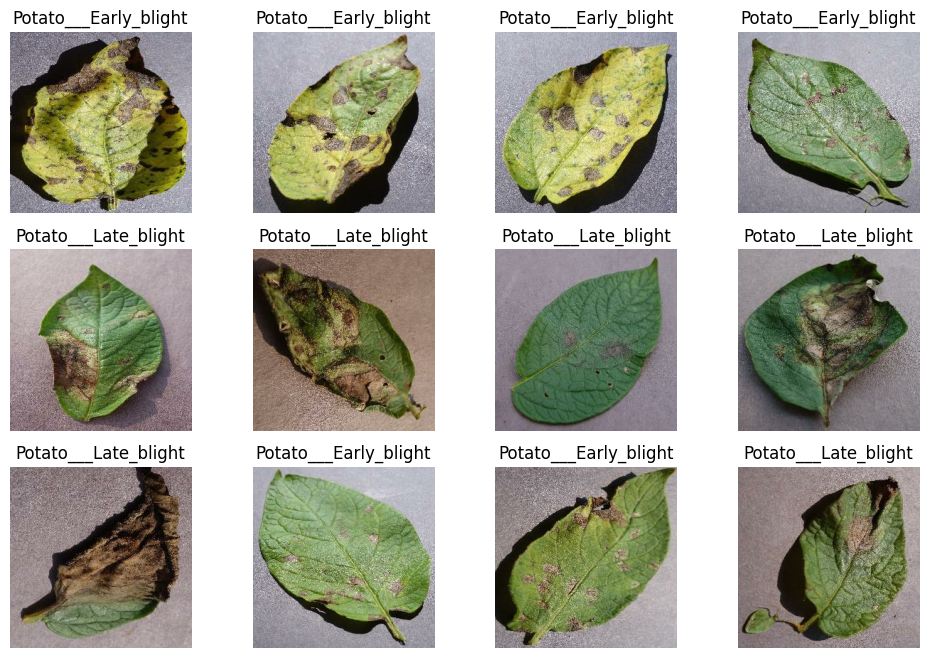

In [12]:
for image_batch, label_batch in dataset.take(1):
    plt.figure(figsize= (12,8))
    for i in range(12):
        ax = plt.subplot(3,4, i+1)
        plt.imshow(image_batch[i].numpy().astype('uint8'))
        plt.title(classes_name[label_batch[i]])
        plt.axis("off")

In [13]:
train_size = 0.8
test_size = 0.1
val_size = 0.1

In [14]:
print(len(dataset)*train_size)
print(len(dataset)*test_size)
print(len(dataset)*val_size)

54.400000000000006
6.800000000000001
6.800000000000001


In [15]:
train_ds = dataset.take(54)
test_ds = dataset.skip(54)
val_ds = test_ds.take(6)
test_ds = test_ds.skip(6)

In [16]:
print(len(train_ds))
print(len(test_ds))
print(len(val_ds))

54
8
6


In [17]:
def get_dataset_partitions_tf(ds, train_split = 0.8, test_split = 0.1, val_split = 0.1, shuffle = True, shuffle_size = 10000 ):
    assert (train_split + test_split + val_split ) == 1
    
    ds_size  = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed = 12)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [18]:
train_ds , val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [19]:
len(train_ds)

54

## Cache, Shuffle, and Prefetch the Dataset


In [20]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size= tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

In [21]:
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.Rescaling(1./255),
])

In [22]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [23]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [25]:
model = Sequential()

model.add(layers.Input(shape = (256,256,3)))
model.add(resize_and_rescale)

model.add(Conv2D(32,(3,3), activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3), activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3), activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3), activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3), activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3), activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(64, activation = 'relu'))
model.add(Dense(3, activation = 'softmax'))

In [26]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ['accuracy']
)

In [28]:
history = model.fit(
    train_ds,
    batch_size = BATCH_SIZE,
    validation_data = val_ds,
    verbose = 1,
    epochs = 30
)

Epoch 1/30


2026-09-09 07:55:36.139663: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-09 07:55:36.458319: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 2/54 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.4453 - loss: 1.0873  

I0000 00:00:1788940539.915146      77 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


54/54 ━━━━━━━━━━━━━━━━━━━━ 32s 369ms/step - accuracy: 0.5156 - loss: 0.9173 - val_accuracy: 0.4792 - val_loss: 0.9118
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 312ms/step - accuracy: 0.7436 - loss: 0.6408 - val_accuracy: 0.8021 - val_loss: 0.5227
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 317ms/step - accuracy: 0.8061 - loss: 0.4635 - val_accuracy: 0.8333 - val_loss: 0.4088
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 307ms/step - accuracy: 0.8588 - loss: 0.3470 - val_accuracy: 0.8802 - val_loss: 0.3008
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 309ms/step - accuracy: 0.8866 - loss: 0.2940 - val_accuracy: 0.9010 - val_loss: 0.2646
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 306ms/step - accuracy: 0.8999 - loss: 0.2480 - val_accuracy: 0.9167 - val_loss: 0.2151
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 308ms/step - accuracy: 0.9178 - loss: 0.1955 - val_accuracy: 0.9479 - val_loss: 0.1430
Epoch 8/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 308ms/step - accuracy: 0.9352 - loss: 0.1640 - val_accuracy: 0.932

In [29]:
score = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9570 - loss: 0.0992


In [30]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

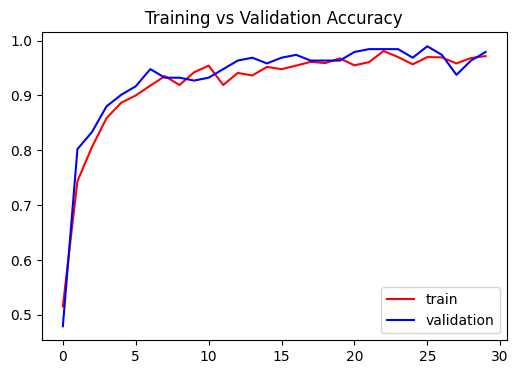

In [31]:
plt.figure(figsize = (6,4))

plt.plot(history.history['accuracy'], color = 'red', label = 'train')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'validation')
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

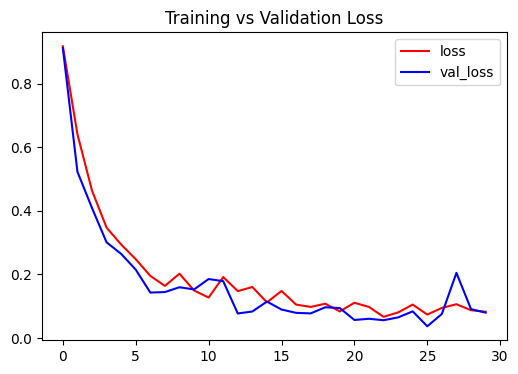

In [32]:
plt.figure(figsize = (6,4))

plt.plot(history.history['loss'], color = 'red', label = 'loss')
plt.plot(history.history['val_loss'], color = 'blue', label = 'val_loss')
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [33]:
score

[0.09919233620166779, 0.95703125]

first image to predict
actual label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
predicted label: Potato___Late_blight


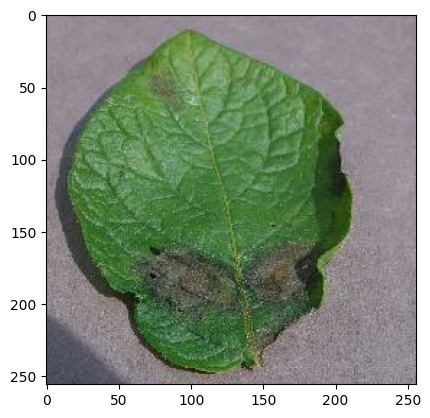

In [34]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",classes_name[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",classes_name[np.argmax(batch_prediction[0])])